In [7]:
# Cell 1 - Setup & imports
import os, time, json, inspect
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import optuna
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

# repo helpers
import sys
sys.path.append("..")
from src.artifacts import ensure_artifact_dirs, save_json_with_manifest, save_joblib_with_manifest
# we will try to import helpers from src.transforms; if missing we'll construct fallback
from src.transforms import (
    numeric_features, categorical_features,
    get_preprocessor, get_feature_names_from_preprocessor, compute_categories_list
)

# Optional helper from transforms (may or may not exist)
try:
    from src.transforms import get_preprocessor_fixed, select_cols_indices
except Exception:
    get_preprocessor_fixed = None
    # we still expect select_cols_indices available; if not, we will not use it here.

# constants / dirs
SEED = 42
ART_ROOT = "../artifacts"
FS_DIR = os.path.join(ART_ROOT, "feature_selection")
TUNE_DIR = os.path.join(ART_ROOT, "tuning_optuna")
os.makedirs(TUNE_DIR, exist_ok=True)
ensure_artifact_dirs()
print("Artifacts root:", ART_ROOT)


Artifacts root: ../artifacts


In [8]:
# Cell 2 - prepare transformed train arrays (fit fixed preprocessor on TRAIN only)

# Load train/hold CSVs created earlier
train_path = os.path.join(ART_ROOT, "data", "train.csv")
hold_path  = os.path.join(ART_ROOT, "data", "holdout.csv")
assert Path(train_path).exists(), f"Missing train CSV at {train_path}"

train_df = pd.read_csv(train_path)
X_train = train_df.drop(columns=["num"])
y_train_arr = train_df["num"].values

# load feature_index_map if present (contains categories_list / full_feature_names)
featmap_path = os.path.join(FS_DIR, "feature_index_map.json")
featmap = None
if Path(featmap_path).exists():
    featmap = json.load(open(featmap_path))
    full_feature_names = featmap.get("full_feature_names")
    categories_list = featmap.get("categories_list")
    print("Loaded feature_index_map.json")
else:
    full_feature_names = None
    categories_list = None
    print("feature_index_map.json not found — we'll compute categories_list from train set.")

# Build or load a preprocessor that uses fixed categories (so CV folds yield same one-hot dims)
featmap = json.load(open(featmap_path))
full_feature_names = featmap["full_feature_names"]
categories_list = featmap["categories_list"]

print("Loaded feature_index_map.json (authoritative)")

from src.transforms import get_preprocessor_fixed
preproc_fixed = get_preprocessor_fixed(categories_list=categories_list)

# Fit preprocessor on TRAIN only (no leakage)
preproc_fixed.fit(X_train)
X_train_trans = preproc_fixed.transform(X_train)  # dense numpy typically
print("X_train_trans shape:", getattr(X_train_trans, "shape", None))

# If full_feature_names not loaded earlier, compute now from fitted preprocessor
if full_feature_names is None:
    try:
        full_feature_names = get_feature_names_from_preprocessor(preproc_fixed, X_train.columns.tolist())
        print("Derived full_feature_names from preprocessor.")
    except Exception as e:
        print("Warning: couldn't derive feature names automatically:", e)
        # fallback: use numeric_features + dummy names for one-hot (not preferred)
        full_feature_names = [str(i) for i in range(X_train_trans.shape[1])]

# Save transformed arrays & metadata for later reuse
np.save(os.path.join(ART_ROOT, "preprocessor", "train_transformed.npy"), X_train_trans)
np.save(os.path.join(ART_ROOT, "preprocessor", "train_y.npy"), y_train_arr)
save_joblib_with_manifest(preproc_fixed, os.path.join(ART_ROOT, "preprocessor", "preprocessor_fixed.joblib"),
                          name="preprocessor_fixed", notes="Fitted on train for tuning")

print("Saved train_transformed.npy, train_y.npy, preprocessor_fixed.joblib and feature_index_map_from_tuning.json")


Loaded feature_index_map.json
Loaded feature_index_map.json (authoritative)
X_train_trans shape: (736, 25)
Saved train_transformed.npy, train_y.npy, preprocessor_fixed.joblib and feature_index_map_from_tuning.json


In [9]:
# Cell 3 - robust eval + objective factory

import inspect
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

def eval_params_cv(params, top_indices, X_trans, y, n_splits=5,
                   early_stopping_rounds=25, seed=SEED, verbose=False):
    """
    Evaluate XGBoost params using Stratified K-fold on transformed matrix X_trans.
    Returns (mean_auc, std_auc)
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    aucs = []
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trans, y), start=1):
        X_tr_all = np.asarray(X_trans)[tr_idx]; X_val_all = np.asarray(X_trans)[val_idx]
        y_tr = np.asarray(y)[tr_idx]; y_val = np.asarray(y)[val_idx]
        X_tr = X_tr_all[:, top_indices]; X_val = X_val_all[:, top_indices]

        wrapper_params = params.copy()
        n_est = int(wrapper_params.pop("n_estimators", 100))

        clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=seed, **wrapper_params)
        # Try sklearn wrapper with early stopping if supported
        try:
            sig = inspect.signature(clf.fit)
            if "early_stopping_rounds" in sig.parameters:
                clf.set_params(n_estimators=n_est)
                clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], early_stopping_rounds=early_stopping_rounds, verbose=False)
                preds = clf.predict_proba(X_val)[:,1]
                aucs.append(roc_auc_score(y_val, preds))
                if verbose: print(f" fold {fold} sklearn wrapper AUC: {aucs[-1]:.4f}")
                continue
        except Exception:
            pass

        # Fallback to xgboost.train
        xgb_params = {"objective":"binary:logistic", "eval_metric":"logloss", "verbosity":0, "seed":seed}
        for name in ("max_depth","learning_rate","subsample","colsample_bytree","reg_alpha","reg_lambda","min_child_weight","gamma"):
            if name in params:
                xgb_params[name] = params[name]
        dtrain = xgb.DMatrix(X_tr, label=y_tr)
        dval = xgb.DMatrix(X_val, label=y_val)
        num_round = int(params.get("n_estimators", n_est))
        bst = xgb.train(params=xgb_params, dtrain=dtrain, num_boost_round=num_round, evals=[(dtrain,"train"),(dval,"valid")],
                        early_stopping_rounds=early_stopping_rounds, verbose_eval=False)
        preds = bst.predict(dval, iteration_range=(0, bst.best_iteration + 1))
        aucs.append(roc_auc_score(y_val, preds))
        if verbose: print(f" fold {fold} xgb.train AUC: {aucs[-1]:.4f}")

    return float(np.mean(aucs)), float(np.std(aucs))


def make_objective(X_trans, y, top_indices, n_splits=5, early_stopping_rounds=25, seed=SEED):
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=50),
            "max_depth": trial.suggest_int("max_depth", 2, 8),
            "learning_rate": trial.suggest_float("learning_rate", 1e-2, 0.2, log=True),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        }
        mean_auc, std_auc = eval_params_cv(params, top_indices, X_trans, y, n_splits=n_splits,
                                           early_stopping_rounds=early_stopping_rounds, seed=seed)
        trial.set_user_attr("mean_auc", mean_auc)
        trial.set_user_attr("std_auc", std_auc)
        return mean_auc
    return objective


In [10]:
# Cell 4 - run Optuna tuning for selected k values

# load X_train_trans and y_train_arr if not in memory
if 'X_train_trans' not in globals():
    X_train_trans = np.load(os.path.join(ART_ROOT, "preprocessor", "train_transformed.npy"))
if 'y_train_arr' not in globals():
    y_train_arr = np.load(os.path.join(ART_ROOT, "preprocessor", "train_y.npy"))

# load df_rank (feature ranking)
rank_path = os.path.join(FS_DIR, "feature_ranks.json")
if Path(rank_path).exists():
    df_rank = pd.read_json(rank_path, orient="records")
else:
    raise FileNotFoundError(f"feature_ranks.json not found at {rank_path}")

# tuning params
k_list = [15, 16]         # change as needed
n_trials = 40             # reduce if slow
n_splits = 5
early_stopping_rounds = 25

for k in k_list:
    print("\n=== Tuning k =", k, "===")
    top_features = df_rank['feature'].tolist()[:k]
    top_indices = [full_feature_names.index(f) for f in top_features]

    objective = make_objective(X_train_trans, y_train_arr, top_indices, n_splits=n_splits,
                               early_stopping_rounds=early_stopping_rounds, seed=SEED)
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    t0 = time.time()
    # if your optuna version doesn't accept show_progress_bar, remove kwarg
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    dur = time.time()-t0

    out_pref = os.path.join(TUNE_DIR, f"optuna_k{k}")
    joblib.dump(study, out_pref + "_study.joblib")
    json.dump({
        "k": k,
        "top_features": top_features,
        "best_params": study.best_trial.params,
        "best_value": study.best_value,
        "n_trials": n_trials,
        "duration_seconds": dur
    }, open(out_pref + "_best.json", "w"), indent=2)
    print(f"Done k={k} best_auc={study.best_value:.4f} saved: {out_pref}_best.json")


[I 2026-04-24 00:39:31,528] A new study created in memory with name: no-name-8b7308c3-0109-4bb8-b719-0a07141aaeba



=== Tuning k = 15 ===


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-04-24 00:39:32,917] Trial 0 finished with value: 0.883259644601108 and parameters: {'n_estimators': 450, 'max_depth': 8, 'learning_rate': 0.08960785365368121, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.4936111842654619, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'min_child_weight': 9, 'gamma': 3.005575058716044}. Best is trial 0 with value: 0.883259644601108.
[I 2026-04-24 00:39:33,894] Trial 1 finished with value: 0.8806304340044177 and parameters: {'n_estimators': 750, 'max_depth': 2, 'learning_rate': 0.18276027831785724, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.5274034664069657, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 4.4734294104626844e-07, 'min_child_weight': 4, 'gamma': 2.6237821581611893}. Best is trial 0 with value: 0.883259644601108.
[I 2026-04-24 00:39:35,007] Trial 2 finished with value: 0.8796180623551898 and parameters: {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.06252287916406217, 'su

[I 2026-04-24 00:39:55,514] Trial 20 finished with value: 0.8783064471411354 and parameters: {'n_estimators': 850, 'max_depth': 2, 'learning_rate': 0.1457724072717944, 'subsample': 0.863768631339208, 'colsample_bytree': 0.9875144835775549, 'reg_alpha': 0.3526010492819689, 'reg_lambda': 0.0004368530915784802, 'min_child_weight': 4, 'gamma': 0.5854117658759614}. Best is trial 12 with value: 0.8860027240650548.
[I 2026-04-24 00:39:56,389] Trial 21 finished with value: 0.8834525190758253 and parameters: {'n_estimators': 900, 'max_depth': 3, 'learning_rate': 0.06406602797393342, 'subsample': 0.9918642460928584, 'colsample_bytree': 0.6372864394043354, 'reg_alpha': 3.532471529879694e-05, 'reg_lambda': 4.723605895762574e-06, 'min_child_weight': 7, 'gamma': 0.03021935005955434}. Best is trial 12 with value: 0.8860027240650548.
[I 2026-04-24 00:39:57,889] Trial 22 finished with value: 0.8846706239660168 and parameters: {'n_estimators': 1000, 'max_depth': 3, 'learning_rate': 0.03686274807234886, 

[I 2026-04-24 00:40:18,358] A new study created in memory with name: no-name-d6d08b04-af9e-436f-be68-503020dcb67d


[I 2026-04-24 00:40:18,270] Trial 39 finished with value: 0.8819498227357305 and parameters: {'n_estimators': 350, 'max_depth': 4, 'learning_rate': 0.105979243193193, 'subsample': 0.7955359636640071, 'colsample_bytree': 0.5189586593162364, 'reg_alpha': 1.475528135065295e-06, 'reg_lambda': 1.1534982088706013e-05, 'min_child_weight': 9, 'gamma': 2.9351732345868102}. Best is trial 31 with value: 0.8860661931664641.
Done k=15 best_auc=0.8861 saved: ../artifacts\tuning_optuna\optuna_k15_best.json

=== Tuning k = 16 ===


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-04-24 00:40:19,794] Trial 0 finished with value: 0.8827057876380369 and parameters: {'n_estimators': 450, 'max_depth': 8, 'learning_rate': 0.08960785365368121, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.4936111842654619, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'min_child_weight': 9, 'gamma': 3.005575058716044}. Best is trial 0 with value: 0.8827057876380369.
[I 2026-04-24 00:40:21,215] Trial 1 finished with value: 0.8805670386022688 and parameters: {'n_estimators': 750, 'max_depth': 2, 'learning_rate': 0.18276027831785724, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.5274034664069657, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 4.4734294104626844e-07, 'min_child_weight': 4, 'gamma': 2.6237821581611893}. Best is trial 0 with value: 0.8827057876380369.
[I 2026-04-24 00:40:22,832] Trial 2 finished with value: 0.8782262553265262 and parameters: {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.06252287916406217, 

[I 2026-04-24 00:40:48,093] Trial 20 finished with value: 0.8791710903770523 and parameters: {'n_estimators': 850, 'max_depth': 6, 'learning_rate': 0.06629426324073376, 'subsample': 0.6302070801194379, 'colsample_bytree': 0.797687599943642, 'reg_alpha': 0.3526010492819689, 'reg_lambda': 0.6233400519437848, 'min_child_weight': 7, 'gamma': 3.844836294316397}. Best is trial 12 with value: 0.8834708561537831.
[I 2026-04-24 00:40:50,190] Trial 21 finished with value: 0.8815949011341966 and parameters: {'n_estimators': 650, 'max_depth': 8, 'learning_rate': 0.01520112060358356, 'subsample': 0.5699070608912998, 'colsample_bytree': 0.4001715759699722, 'reg_alpha': 6.860273980915173e-06, 'reg_lambda': 5.2573355079469225e-05, 'min_child_weight': 3, 'gamma': 4.779663713631936}. Best is trial 12 with value: 0.8834708561537831.
[I 2026-04-24 00:40:51,045] Trial 22 finished with value: 0.8821186642324852 and parameters: {'n_estimators': 750, 'max_depth': 8, 'learning_rate': 0.027837312341052967, 'sub

In [17]:
# Cell 5 — retrain final model(s) and evaluate on holdout (CLEAN VERSION)

hold_trans_path = os.path.join(ART_ROOT, "preprocessor", "hold_transformed.npy")
hold_y_path = os.path.join(ART_ROOT, "preprocessor", "hold_y.npy")

have_holdout = Path(hold_trans_path).exists() and Path(hold_y_path).exists()

if have_holdout:
    X_hold_trans = np.load(hold_trans_path)
    y_hold_arr = np.load(hold_y_path)
    print("Holdout loaded:", X_hold_trans.shape, y_hold_arr.shape)


def train_final_and_save(best_params, top_indices, X_trans, y, save_base, seed=SEED):
    """
    Train final XGBoost model using sklearn wrapper ONLY (no booster fallback)
    """
    X_sel = np.asarray(X_trans)[:, top_indices]

    model = xgb.XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=seed,
        **best_params
    )

    model.fit(X_sel, y)

    # Save model
    model_path = save_base + ".joblib"
    joblib.dump(model, model_path)

    return {
        "saved_as": "sklearn_wrapper",
        "path": model_path
    }


for k in k_list:
    best_json = os.path.join(TUNE_DIR, f"optuna_k{k}_best.json")

    if not Path(best_json).exists():
        print("Best params missing for k =", k, "skip")
        continue

    info = json.load(open(best_json))
    best_params = info["best_params"]
    top_features = info["top_features"]

    top_indices = [full_feature_names.index(f) for f in top_features]

    save_base = os.path.join(TUNE_DIR, f"xgb_k{k}_final")

    meta = train_final_and_save(
        best_params,
        top_indices,
        X_train_trans,
        y_train_arr,
        save_base
    )

    meta["k"] = k
    meta["top_features"] = top_features

    json.dump(meta, open(save_base + "_meta.json", "w"), indent=2)

    print("Saved final model meta:", meta)

    # Holdout evaluation
    if have_holdout:
        model = joblib.load(meta["path"])
        preds = model.predict_proba(X_hold_trans[:, top_indices])[:, 1]

        auc = roc_auc_score(y_hold_arr, preds)
        print(f" Holdout AUC for k={k}: {auc:.4f}")

        json.dump(
            {"k": k, "hold_auc": float(auc)},
            open(save_base + "_hold_eval.json", "w"),
            indent=2
        )

Holdout loaded: (184, 29) (184,)
Saved final model meta: {'saved_as': 'sklearn_wrapper', 'path': '../artifacts/tuning_optuna\\xgb_k15_final.joblib', 'k': 15, 'top_features': ['cp_asymptomatic', 'cp_atypical angina', 'sex_Female', 'thal_normal', 'ca', 'chol', 'oldpeak', 'age', 'slope_flat', 'thal_reversable defect', 'restecg_normal', 'cp_typical angina', 'cp_non-anginal', 'thalch', 'restecg_st-t abnormality']}
 Holdout AUC for k=15: 0.9144
Saved final model meta: {'saved_as': 'sklearn_wrapper', 'path': '../artifacts/tuning_optuna\\xgb_k16_final.joblib', 'k': 16, 'top_features': ['cp_asymptomatic', 'cp_atypical angina', 'sex_Female', 'thal_normal', 'ca', 'chol', 'oldpeak', 'age', 'slope_flat', 'thal_reversable defect', 'restecg_normal', 'cp_typical angina', 'cp_non-anginal', 'thalch', 'restecg_st-t abnormality', 'restecg_lv hypertrophy']}
 Holdout AUC for k=16: 0.9144


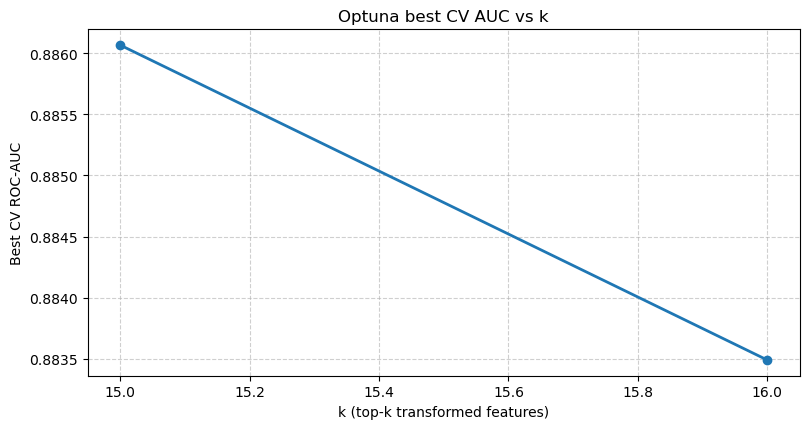

In [18]:
# Cell 6 - plot best CV AUC per k (if saved)
import matplotlib.pyplot as plt
rows = []
for k in k_list:
    p = os.path.join(TUNE_DIR, f"optuna_k{k}_best.json")
    if Path(p).exists():
        info = json.load(open(p))
        rows.append({"k":info["k"], "best_auc": info["best_value"]})
if rows:
    df = pd.DataFrame(rows).sort_values("k")
    plt.figure(figsize=(8,4))
    plt.plot(df['k'], df['best_auc'], marker='o', linewidth=2)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.xlabel("k (top-k transformed features)")
    plt.ylabel("Best CV ROC-AUC")
    plt.title("Optuna best CV AUC vs k")

    plt.show()
else:
    print("No tuning results to plot.")


k=15 hold AUC=0.9144 AP=0.9314 Brier=0.1200


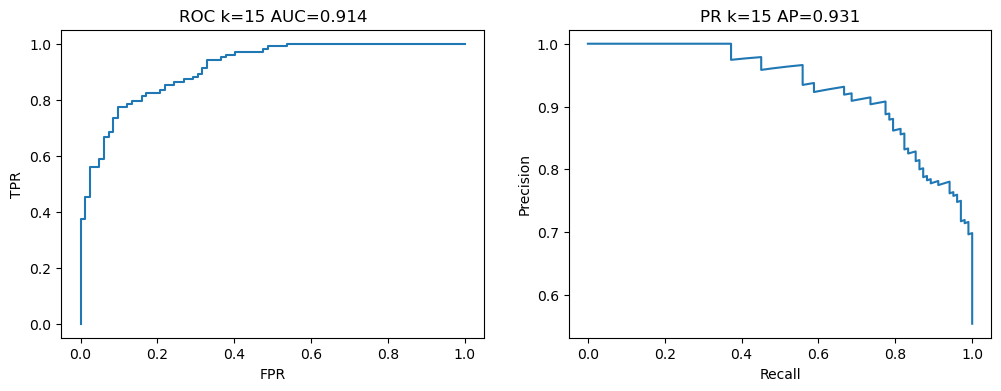

k=16 hold AUC=0.9144 AP=0.9311 Brier=0.1210


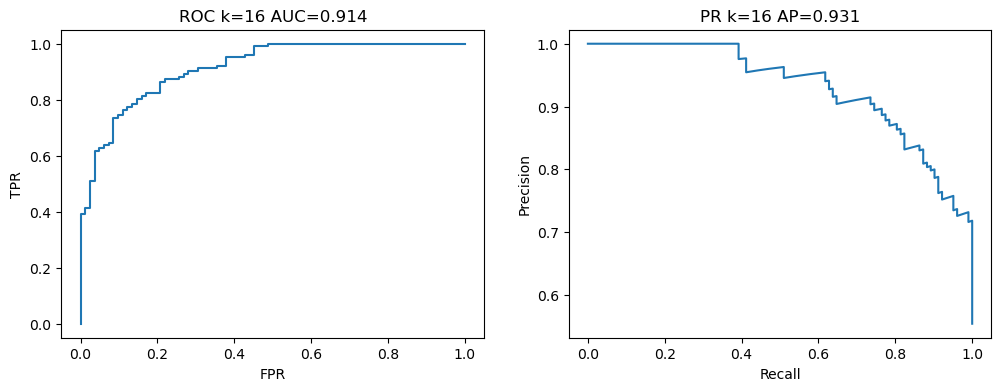

In [20]:
import json, joblib, numpy as np
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, precision_recall_curve, roc_curve
import matplotlib.pyplot as plt
import xgboost as xgb

TUNE_DIR = "../artifacts/tuning_optuna"
# load hold data arrays
X_hold = np.load("../artifacts/preprocessor/hold_transformed.npy")
y_hold = np.load("../artifacts/preprocessor/hold_y.npy")

def load_model_meta(k):
    info = json.load(open(Path(TUNE_DIR)/f"xgb_k{k}_final_meta.json"))
    return info

def predict_from_meta(meta, X, top_indices):
    mdl = joblib.load(meta["path"])
    preds = mdl.predict_proba(X_hold[:, top_indices])[:,1]
    return preds

for k in [15,16]:
    meta = load_model_meta(k)
    top_feats = meta["top_features"]
    # load full_feature_names (from previous saved map)
    featmap = json.load(open("../artifacts/feature_selection/feature_index_map.json"))
    full_feature_names = featmap["full_feature_names"]
    top_indices = [full_feature_names.index(f) for f in top_feats]
    preds = predict_from_meta(meta, X_hold, top_indices)
    auc = roc_auc_score(y_hold, preds)
    ap  = average_precision_score(y_hold, preds)
    brier = brier_score_loss(y_hold, preds)
    print(f"k={k} hold AUC={auc:.4f} AP={ap:.4f} Brier={brier:.4f}")
    fpr, tpr, _ = roc_curve(y_hold, preds)
    prec, rec, _ = precision_recall_curve(y_hold, preds)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1); plt.plot(fpr,tpr); plt.title(f"ROC k={k} AUC={auc:.3f}"); plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.subplot(1,2,2); plt.plot(rec,prec); plt.title(f"PR k={k} AP={ap:.3f}"); plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.show()
